<p align="center">
<img src="https://i.pinimg.com/1200x/f9/89/41/f989413216f630fcf92eda8e79b135f0.jpg" width="1000" height="10">
</p>

# Google Play store Dataset
- This is the data of google play store where more than 1.85 million different apps are available for users to download.
- This apps have come to play huge roles in life today.
- Lets get some observation and conclusion from this data set.

# Dataset

Here we have 13 columns/features in total:

1. **App**: Data type is object; contains app name  
2. **Category**: Object type; category of the app  
3. **Rating**: Float; rating of the app  
4. **Reviews**: Object; number of reviews  
5. **Size**: Object; size of the app  
6. **Installs**: Object; number of installs  
7. **Type**: Object; free or paid  
8. **Price**: Object; price of the app  
9. **Content Rating**: Object; target audience  
10. **Genres**: Object; genre of the app  
11. **Last Updated**: Object; last update date  
12. **Current Ver**: Object; current version  
13. **Android Ver**: Object; required Android version  

# Loading the dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(palette = 'bright')

In [2]:
df = pd.read_csv('/kaggle/input/datasets/lava18/google-play-store-apps/googleplaystore.csv')
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


# 📌 Initial Insights

In [3]:
print("📌 Data set Insights:")
print("-"*70)

summary = {
    "Metric": ["Total Rows", "Total Columns", "Duplicate Rows", "Total Missing Cells", "Memory Usage"],
    "Value": [
        df.shape[0],
        df.shape[1],
        df.duplicated().sum(),
        df.isnull().sum().sum(),
        f"{df.memory_usage().sum()/1024**2:.2f} MB"
    ]
}

info = pd.DataFrame(summary)

styled_info = (
    info.style
    .set_properties(**{
        "background-color": "#111111",
        "color": "white",
        "border": "1px solid gray"
    })
    .set_table_styles([
        {"selector": "th", "props": [("background-color", "#2c2c2c"), ("color", "white")]}
    ])
)

display(styled_info)

📌 Data set Insights:
----------------------------------------------------------------------


,Metric,Value
0,Total Rows,10841
1,Total Columns,13
2,Duplicate Rows,483
3,Total Missing Cells,1487
4,Memory Usage,1.08 MB


In [4]:
print("📌 Feature Information:")
print("-"*70)

info_df = pd.DataFrame({
    "Columns": df.columns,
    "Data Type": df.dtypes,
    "Not Null Count": df.notnull().sum(),
    "Null values": df.isnull().sum(),
    "Unique Values": df.nunique(),
    "Duplicate Values": df.apply(lambda x: x.duplicated().sum())
})

style_info = info_df.style.set_properties(**{
    "background-color": "#111111",
    "color": "white",
    "border": "1px solid gray"
})

display(style_info)

📌 Feature Information:
----------------------------------------------------------------------


,Columns,Data Type,Not Null Count,Null values,Unique Values,Duplicate Values
App,App,object,10841,0,9660,1181
Category,Category,object,10841,0,34,10807
Rating,Rating,float64,9367,1474,40,10800
Reviews,Reviews,object,10841,0,6002,4839
Size,Size,object,10841,0,462,10379
Installs,Installs,object,10841,0,22,10819
Type,Type,object,10840,1,3,10837
Price,Price,object,10841,0,93,10748
Content Rating,Content Rating,object,10840,1,6,10834
Genres,Genres,object,10841,0,120,10721


In [5]:
df.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


## 💡 Conclusion
- Over here we can see that apart from rating, all other feature are data type.
- So we need to convert those feature which as numeric value and are object like: 'Review','size','Installs','Price','last updated'
- In the Rating feature, we can see that there are many missing values present so we need to handle them as well by using mean or median depending if the data is symmetric or skewed not.
- Here we can see that there are many dupliated values present but for such data sets, we will have many dupliates so
- Several features in the dataset contain a high number of duplicate values. This is expected because many columns represent categorical or limited-range attributes such as Category, Type, Content Rating, and Installs. These variables naturally repeat across many applications since multiple apps can belong to the same category, share similar installation ranges, or have identical content ratings

# ⚙️ Data processing
- Here we will convert feature like: 'review', 'Price', 'Install', 'Last Updated' into numeric data type.

## Feature: Reviews

In [6]:
df['Reviews'].unique()

array(['159', '967', '87510', ..., '603', '1195', '398307'], dtype=object)

In [7]:
df['Reviews'].str.isnumeric().sum()

np.int64(10840)

In [8]:
df[~df['Reviews'].str.isnumeric()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [9]:
df = df.drop(df.index[10472])
df[~df['Reviews'].str.isnumeric()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver


In [10]:
df['Reviews'] = df['Reviews'].astype(int)

In [11]:
print("📌 Feature Information after changing the datatype of reviews:")
print("-"*70)

info_df = pd.DataFrame({
    "Columns": df.columns,
    "Data Type": df.dtypes,
    "Not Null Count": df.notnull().sum(),
    "Null values": df.isnull().sum(),
    "Unique Values": df.nunique(),
    "Duplicate Values": df.apply(lambda x: x.duplicated().sum())
})

style_info = info_df.style.set_properties(**{
    "background-color": "#111111",
    "color": "white",
    "border": "1px solid gray"
})

display(style_info)

📌 Feature Information after changing the datatype of reviews:
----------------------------------------------------------------------


,Columns,Data Type,Not Null Count,Null values,Unique Values,Duplicate Values
App,App,object,10840,0,9659,1181
Category,Category,object,10840,0,33,10807
Rating,Rating,float64,9366,1474,39,10800
Reviews,Reviews,int64,10840,0,6001,4839
Size,Size,object,10840,0,461,10379
Installs,Installs,object,10840,0,21,10819
Type,Type,object,10839,1,2,10837
Price,Price,object,10840,0,92,10748
Content Rating,Content Rating,object,10840,0,6,10834
Genres,Genres,object,10840,0,119,10721


### 💡Conclusion:
- Here we have first checked that all the values in the reviews column are numeric or not by using isnumeric fucntion.
- We found that there is 1 value which is not numeric in nature so to track that we used the '~'(not) symbol to find that which row it is.
- Once found, we removed that data from the dataset then used astype(int) to convert the data into int.

In [12]:
df_copy = df.copy()

## Feature: Size

In [13]:
df['Size'].unique()

array(['19M', '14M', '8.7M', '25M', '2.8M', '5.6M', '29M', '33M', '3.1M',
       '28M', '12M', '20M', '21M', '37M', '2.7M', '5.5M', '17M', '39M',
       '31M', '4.2M', '7.0M', '23M', '6.0M', '6.1M', '4.6M', '9.2M',
       '5.2M', '11M', '24M', 'Varies with device', '9.4M', '15M', '10M',
       '1.2M', '26M', '8.0M', '7.9M', '56M', '57M', '35M', '54M', '201k',
       '3.6M', '5.7M', '8.6M', '2.4M', '27M', '2.5M', '16M', '3.4M',
       '8.9M', '3.9M', '2.9M', '38M', '32M', '5.4M', '18M', '1.1M',
       '2.2M', '4.5M', '9.8M', '52M', '9.0M', '6.7M', '30M', '2.6M',
       '7.1M', '3.7M', '22M', '7.4M', '6.4M', '3.2M', '8.2M', '9.9M',
       '4.9M', '9.5M', '5.0M', '5.9M', '13M', '73M', '6.8M', '3.5M',
       '4.0M', '2.3M', '7.2M', '2.1M', '42M', '7.3M', '9.1M', '55M',
       '23k', '6.5M', '1.5M', '7.5M', '51M', '41M', '48M', '8.5M', '46M',
       '8.3M', '4.3M', '4.7M', '3.3M', '40M', '7.8M', '8.8M', '6.6M',
       '5.1M', '61M', '66M', '79k', '8.4M', '118k', '44M', '695k', '1.6M',
     

In [14]:
(df['Size'] == 'Varies with device').sum()

np.int64(1695)

In [15]:
df['Size'].isnull().sum()

np.int64(0)

In [16]:
df['Size'] = df['Size'].str.replace('M','000')
df['Size'] = df['Size'].str.replace('k','')
df['Size'] = df['Size'].replace('Varies with device',np.nan)
df['Size'] = df['Size'].astype(float)

In [17]:
print("📌 Feature Information after changing the datatype of size:")
print("-"*70)

info_df = pd.DataFrame({
    "Columns": df.columns,
    "Data Type": df.dtypes,
    "Not Null Count": df.notnull().sum(),
    "Null values": df.isnull().sum(),
    "Unique Values": df.nunique(),
    "Duplicate Values": df.apply(lambda x: x.duplicated().sum())
})

style_info = info_df.style.set_properties(**{
    "background-color": "#111111",
    "color": "white",
    "border": "1px solid gray"
})

display(style_info)

📌 Feature Information after changing the datatype of size:
----------------------------------------------------------------------


,Columns,Data Type,Not Null Count,Null values,Unique Values,Duplicate Values
App,App,object,10840,0,9659,1181
Category,Category,object,10840,0,33,10807
Rating,Rating,float64,9366,1474,39,10800
Reviews,Reviews,int64,10840,0,6001,4839
Size,Size,float64,9145,1695,459,10380
Installs,Installs,object,10840,0,21,10819
Type,Type,object,10839,1,2,10837
Price,Price,object,10840,0,92,10748
Content Rating,Content Rating,object,10840,0,6,10834
Genres,Genres,object,10840,0,119,10721


### 💡 Conclusion:
- Here as we can see that there are 1695 rows having value as 'Varies with device'. So they all became null.
- To handle this missing values, we need to use mean on median depending on how symmetric the graph is.

## Feature: Installs

In [18]:
df.head(2)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up


In [19]:
df['Installs'].unique()

array(['10,000+', '500,000+', '5,000,000+', '50,000,000+', '100,000+',
       '50,000+', '1,000,000+', '10,000,000+', '5,000+', '100,000,000+',
       '1,000,000,000+', '1,000+', '500,000,000+', '50+', '100+', '500+',
       '10+', '1+', '5+', '0+', '0'], dtype=object)

In [20]:
df['Installs'] = df['Installs'].str.replace(",","")
df['Installs'] = df['Installs'].str.replace("+","")
df['Installs'] = df['Installs'].astype('int')

In [21]:
df.head(2)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,10000,Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,500000,Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up


In [22]:
print("📌 Feature Information after changing the datatype of Installs:")
print("-"*70)

info_df = pd.DataFrame({
    "Columns": df.columns,
    "Data Type": df.dtypes,
    "Not Null Count": df.notnull().sum(),
    "Null values": df.isnull().sum(),
    "Unique Values": df.nunique(),
    "Duplicate Values": df.apply(lambda x: x.duplicated().sum())
})

style_info = info_df.style.set_properties(**{
    "background-color": "#111111",
    "color": "white",
    "border": "1px solid gray"
})

display(style_info)

📌 Feature Information after changing the datatype of Installs:
----------------------------------------------------------------------


,Columns,Data Type,Not Null Count,Null values,Unique Values,Duplicate Values
App,App,object,10840,0,9659,1181
Category,Category,object,10840,0,33,10807
Rating,Rating,float64,9366,1474,39,10800
Reviews,Reviews,int64,10840,0,6001,4839
Size,Size,float64,9145,1695,459,10380
Installs,Installs,int64,10840,0,20,10820
Type,Type,object,10839,1,2,10837
Price,Price,object,10840,0,92,10748
Content Rating,Content Rating,object,10840,0,6,10834
Genres,Genres,object,10840,0,119,10721


### 💡 Conclusion:
- Here we have converted the data type of float to int by replacing the ',' and '+' with empty string.

## Feature: Price

In [23]:
df['Price'].unique()

array(['0', '$4.99', '$3.99', '$6.99', '$1.49', '$2.99', '$7.99', '$5.99',
       '$3.49', '$1.99', '$9.99', '$7.49', '$0.99', '$9.00', '$5.49',
       '$10.00', '$24.99', '$11.99', '$79.99', '$16.99', '$14.99',
       '$1.00', '$29.99', '$12.99', '$2.49', '$10.99', '$1.50', '$19.99',
       '$15.99', '$33.99', '$74.99', '$39.99', '$3.95', '$4.49', '$1.70',
       '$8.99', '$2.00', '$3.88', '$25.99', '$399.99', '$17.99',
       '$400.00', '$3.02', '$1.76', '$4.84', '$4.77', '$1.61', '$2.50',
       '$1.59', '$6.49', '$1.29', '$5.00', '$13.99', '$299.99', '$379.99',
       '$37.99', '$18.99', '$389.99', '$19.90', '$8.49', '$1.75',
       '$14.00', '$4.85', '$46.99', '$109.99', '$154.99', '$3.08',
       '$2.59', '$4.80', '$1.96', '$19.40', '$3.90', '$4.59', '$15.46',
       '$3.04', '$4.29', '$2.60', '$3.28', '$4.60', '$28.99', '$2.95',
       '$2.90', '$1.97', '$200.00', '$89.99', '$2.56', '$30.99', '$3.61',
       '$394.99', '$1.26', '$1.20', '$1.04'], dtype=object)

In [24]:
df['Price'] = df['Price'].str.replace('$','')
df['Price'] = df['Price'].astype(float)

In [25]:
print("📌 Feature Information after changing the datatype of Price:")
print("-"*70)

info_df = pd.DataFrame({
    "Columns": df.columns,
    "Data Type": df.dtypes,
    "Not Null Count": df.notnull().sum(),
    "Null values": df.isnull().sum(),
    "Unique Values": df.nunique(),
    "Duplicate Values": df.apply(lambda x: x.duplicated().sum())
})

style_info = info_df.style.set_properties(**{
    "background-color": "#111111",
    "color": "white",
    "border": "1px solid gray"
})

display(style_info)

📌 Feature Information after changing the datatype of Price:
----------------------------------------------------------------------


,Columns,Data Type,Not Null Count,Null values,Unique Values,Duplicate Values
App,App,object,10840,0,9659,1181
Category,Category,object,10840,0,33,10807
Rating,Rating,float64,9366,1474,39,10800
Reviews,Reviews,int64,10840,0,6001,4839
Size,Size,float64,9145,1695,459,10380
Installs,Installs,int64,10840,0,20,10820
Type,Type,object,10839,1,2,10837
Price,Price,float64,10840,0,92,10748
Content Rating,Content Rating,object,10840,0,6,10834
Genres,Genres,object,10840,0,119,10721


### 💡 Conclusion:
Here we have converted the price column to float datatype by removing the dollar sign from it.

## Feature: Last Updated

In [26]:
df['Last Updated'].unique()

array(['January 7, 2018', 'January 15, 2018', 'August 1, 2018', ...,
       'January 20, 2014', 'February 16, 2014', 'March 23, 2014'],
      dtype=object)

In [27]:
df['Last Updated'] = pd.to_datetime(df['Last Updated'])

In [28]:
df['day'] = df['Last Updated'].dt.day
df['month'] = df['Last Updated'].dt.month
df['year'] = df['Last Updated'].dt.year

In [29]:
df.head(2)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,day,month,year
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,7,1,2018
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,15,1,2018


In [30]:
df.rename(columns={'day':'Last Update Day'},inplace = True)
df.rename(columns={'month':'Last Update Month'},inplace = True)
df.rename(columns={'year':'Last Update Year'},inplace = True)

In [31]:
df.drop('Last Updated',axis = 1,inplace = True)

In [32]:
df.head(2)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Current Ver,Android Ver,Last Update Day,Last Update Month,Last Update Year
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,10000,Free,0.0,Everyone,Art & Design,1.0.0,4.0.3 and up,7,1,2018
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2.0.0,4.0.3 and up,15,1,2018


In [33]:
print("📌 Feature Information after changing the datatype of Last update:")
print("-"*70)

info_df = pd.DataFrame({
    "Columns": df.columns,
    "Data Type": df.dtypes,
    "Not Null Count": df.notnull().sum(),
    "Null values": df.isnull().sum(),
    "Unique Values": df.nunique(),
    "Duplicate Values": df.apply(lambda x: x.duplicated().sum())
})

style_info = info_df.style.set_properties(**{
    "background-color": "#111111",
    "color": "white",
    "border": "1px solid gray"
})

display(style_info)

📌 Feature Information after changing the datatype of Last update:
----------------------------------------------------------------------


,Columns,Data Type,Not Null Count,Null values,Unique Values,Duplicate Values
App,App,object,10840,0,9659,1181
Category,Category,object,10840,0,33,10807
Rating,Rating,float64,9366,1474,39,10800
Reviews,Reviews,int64,10840,0,6001,4839
Size,Size,float64,9145,1695,459,10380
Installs,Installs,int64,10840,0,20,10820
Type,Type,object,10839,1,2,10837
Price,Price,float64,10840,0,92,10748
Content Rating,Content Rating,object,10840,0,6,10834
Genres,Genres,object,10840,0,119,10721


### 💡 Conclusion:
- here we have divided the last updated feature into 3 new columns that is day, month and year.
- Here first we have converted this feature to 'to_datetime()' then we have divided this into '.dt.date','.dt.month','.dt.year'

# 🗑️ Remove duplicates
- Here are going to remove duplicate from the feature 'App'.
- As we can see in the df.info, there are 1181 duplicate values present.
- We remove duplicate values mainly to ensure that the analysis is accurate and unbiased. Duplicate rows can distort statistics and visualizations
- Here we are only removing duplicate from App is beacuse App represents the unique entity in the dataset.

In [34]:
df['App'].duplicated().sum()
df[df['App'].duplicated(keep=False)].sort_values('App')

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Current Ver,Android Ver,Last Update Day,Last Update Month,Last Update Year
1393,10 Best Foods for You,HEALTH_AND_FITNESS,4.0,2490,3.8,500000,Free,0.00,Everyone 10+,Health & Fitness,1.9,2.3.3 and up,17,2,2017
1407,10 Best Foods for You,HEALTH_AND_FITNESS,4.0,2490,3.8,500000,Free,0.00,Everyone 10+,Health & Fitness,1.9,2.3.3 and up,17,2,2017
2543,1800 Contacts - Lens Store,MEDICAL,4.7,23160,26000.0,1000000,Free,0.00,Everyone,Medical,7.4.1,5.0 and up,27,7,2018
2322,1800 Contacts - Lens Store,MEDICAL,4.7,23160,26000.0,1000000,Free,0.00,Everyone,Medical,7.4.1,5.0 and up,27,7,2018
2385,2017 EMRA Antibiotic Guide,MEDICAL,4.4,12,3.8,1000,Paid,16.99,Everyone,Medical,1.0.5,4.0.3 and up,27,1,2017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3202,trivago: Hotels & Travel,TRAVEL_AND_LOCAL,4.2,219848,NaN,50000000,Free,0.00,Everyone,Travel & Local,Varies with device,Varies with device,2,8,2018
3118,trivago: Hotels & Travel,TRAVEL_AND_LOCAL,4.2,219848,NaN,50000000,Free,0.00,Everyone,Travel & Local,Varies with device,Varies with device,2,8,2018
3103,trivago: Hotels & Travel,TRAVEL_AND_LOCAL,4.2,219848,NaN,50000000,Free,0.00,Everyone,Travel & Local,Varies with device,Varies with device,2,8,2018
8291,wetter.com - Weather and Radar,WEATHER,4.2,189310,38000.0,10000000,Free,0.00,Everyone,Weather,Varies with device,Varies with device,6,8,2018


In [35]:
df = df.sort_values('Reviews', ascending=False)
df = df.drop_duplicates(subset='App', keep='first')

In [36]:
df['App'].duplicated().sum()

np.int64(0)

In [37]:
print("📌 Feature Information after Removing all the duplicate values from the feature App:")
print("-"*90)

info_df = pd.DataFrame({
    "Columns": df.columns,
    "Data Type": df.dtypes,
    "Not Null Count": df.notnull().sum(),
    "Null values": df.isnull().sum(),
    "Unique Values": df.nunique(),
    "Duplicate Values": df.apply(lambda x: x.duplicated().sum())
})

style_info = info_df.style.set_properties(**{
    "background-color": "#111111",
    "color": "white",
    "border": "1px solid gray"
})

display(style_info)

📌 Feature Information after Removing all the duplicate values from the feature App:
------------------------------------------------------------------------------------------


,Columns,Data Type,Not Null Count,Null values,Unique Values,Duplicate Values
App,App,object,9659,0,9659,0
Category,Category,object,9659,0,33,9626
Rating,Rating,float64,8196,1463,39,9619
Reviews,Reviews,int64,9659,0,5334,4325
Size,Size,float64,8431,1228,459,9199
Installs,Installs,int64,9659,0,20,9639
Type,Type,object,9658,1,2,9656
Price,Price,float64,9659,0,92,9567
Content Rating,Content Rating,object,9659,0,6,9653
Genres,Genres,object,9659,0,118,9541


## 💡 Conclusion
- Here we have first sorted the values based on the reviews that is in descending order so that we can keep the app with most reviews and remove its duplicates.
- Now we dont have any duplicate values present in the app feature.

# 🧹 Handling Missing Values
- Here we have columns 'Rating' with 1463 missing values. 'Size' with 1228 missing values 'type' with 1 missing values 'current ver' with 8 missing values and 'Android ver' with 2 missing values.
- So for the numeric datatype, we can use the graph to find out if the graph is symmetric or skewed and use centeral tendency to fill the missing values.
- For object data type we will use 'mode' to fill the values.

<Axes: xlabel='Rating', ylabel='Count'>

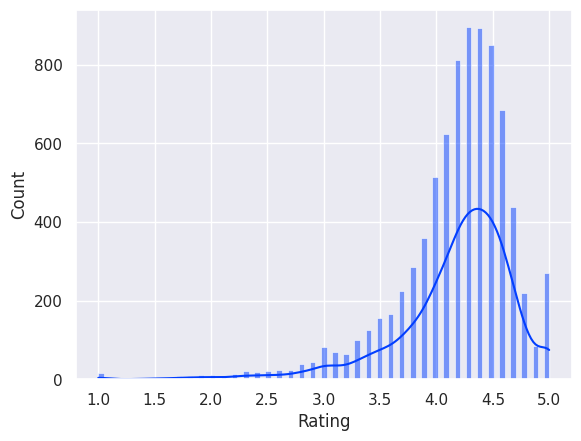

In [38]:
sns.histplot(df['Rating'],kde = True)

In [39]:
df['Rating'] = df['Rating'].fillna(df['Rating'].median())

<Axes: xlabel='Size', ylabel='Count'>

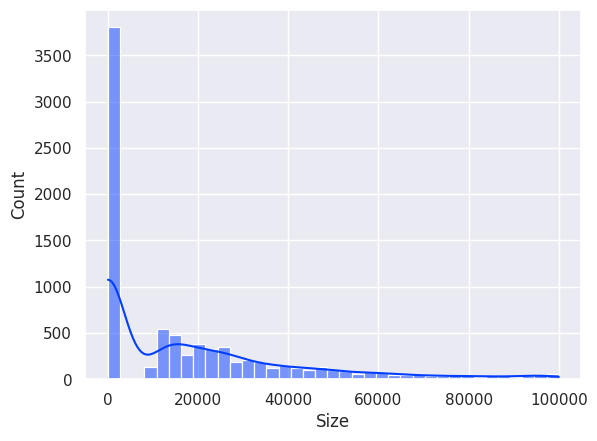

In [40]:
sns.histplot(df['Size'],kde = True)

In [41]:
df['Size'] = df['Size'].fillna(df['Size'].median())

In [42]:
print(df['Type'].unique())
print(df['Type'].mode())

['Free' 'Paid' nan]
0    Free
Name: Type, dtype: object


In [43]:
df['Type'] = df['Type'].fillna('Free')

In [44]:
print(df['Type'].unique())

['Free' 'Paid']


In [45]:
print(df['Current Ver'].unique())
print(df['Current Ver'].mode())

['Varies with device' '10.322.16' '1.90.0' ... '7.1.5' 'V2.3' 'Initial']
0    Varies with device
Name: Current Ver, dtype: object


In [46]:
df['Current Ver'] = df['Current Ver'].fillna('Varies with device')

In [47]:
print(df['Android Ver'].unique())
print(df['Android Ver'].mode())

['Varies with device' '4.1 and up' '4.0 and up' '4.0.3 and up'
 '3.0 and up' '4.4 and up' '4.2 and up' '2.3 and up' '4.3 and up'
 '5.0 and up' '2.3.3 and up' '2.1 and up' '3.1 and up' '2.0.1 and up'
 '2.0 and up' '4.1 - 7.1.1' '2.2 and up' '6.0 and up' '5.0 - 8.0'
 '1.5 and up' '4.0.3 - 7.1.1' '1.6 and up' '7.1 and up' '7.0 and up'
 '3.2 and up' '5.1 and up' '8.0 and up' '5.0 - 6.0' '1.0 and up'
 '4.4W and up' nan '7.0 - 7.1.1' '2.2 - 7.1.1' '5.0 - 7.1.1']
0    4.1 and up
Name: Android Ver, dtype: object


In [48]:
df['Android Ver'] = df['Android Ver'].fillna('4.1 and up')

In [49]:
print("📌 Feature Information after filling in the missing values:")
print("-"*90)

info_df = pd.DataFrame({
    "Columns": df.columns,
    "Data Type": df.dtypes,
    "Not Null Count": df.notnull().sum(),
    "Null values": df.isnull().sum(),
    "Unique Values": df.nunique(),
    "Duplicate Values": df.apply(lambda x: x.duplicated().sum())
})

style_info = info_df.style.set_properties(**{
    "background-color": "#111111",
    "color": "white",
    "border": "1px solid gray"
})

display(style_info)

📌 Feature Information after filling in the missing values:
------------------------------------------------------------------------------------------


,Columns,Data Type,Not Null Count,Null values,Unique Values,Duplicate Values
App,App,object,9659,0,9659,0
Category,Category,object,9659,0,33,9626
Rating,Rating,float64,9659,0,39,9620
Reviews,Reviews,int64,9659,0,5334,4325
Size,Size,float64,9659,0,459,9200
Installs,Installs,int64,9659,0,20,9639
Type,Type,object,9659,0,2,9657
Price,Price,float64,9659,0,92,9567
Content Rating,Content Rating,object,9659,0,6,9653
Genres,Genres,object,9659,0,118,9541


## 💡 Conclusion
- Here the Rating cloumn was left skewed so we had to use the median to fill up the missing values as mean is highly affected by the outliers present in the data.
- Then when we come to column size, the data was right skewwed so we had to use median to fill up the missing data.
- Now when it comes to categorical data that is column: 'Android ver', 'Current ver' and 'Type', we had to fill them with mode.
- So now we dont have any missing values present in the data and now we can start with EDA

# 📊 Visualization: Univariate Analysis

## 🔢 Numerical Feature

In [50]:
df['Reviews'].describe()

count    9.659000e+03
mean     2.168041e+05
std      1.831430e+06
min      0.000000e+00
25%      2.500000e+01
50%      9.690000e+02
75%      2.945350e+04
max      7.815831e+07
Name: Reviews, dtype: float64

In [51]:
df['Reviews'].skew()

np.float64(26.5697582111809)

In [52]:
df['Reviews_log'] = np.log1p(df['Reviews'])
df['Reviews_log'].skew()

np.float64(0.045333141224661595)

<Axes: xlabel='Reviews_log', ylabel='Count'>

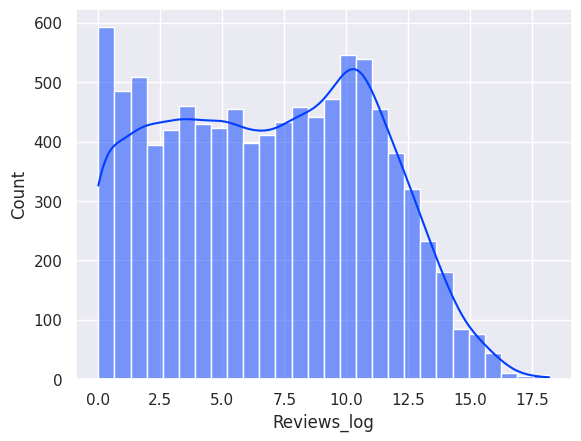

In [53]:
sns.histplot(df['Reviews_log'], kde=True)

<Axes: xlabel='Reviews_log'>

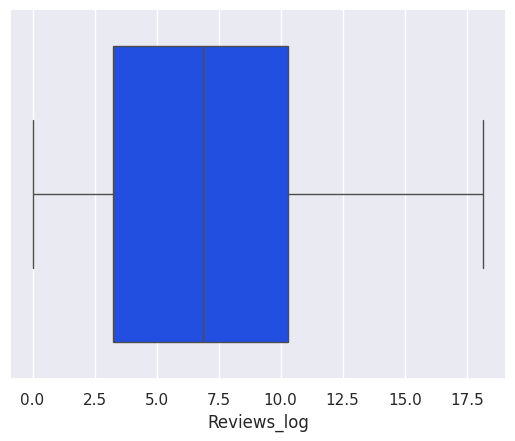

In [54]:
sns.boxplot(x = df['Reviews_log'])

<Axes: xlabel='Rating', ylabel='Count'>

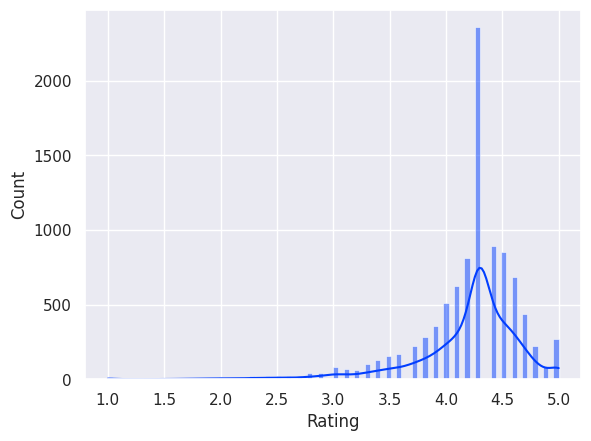

In [55]:
sns.histplot(df['Rating'], kde = True)

<Axes: xlabel='Rating'>

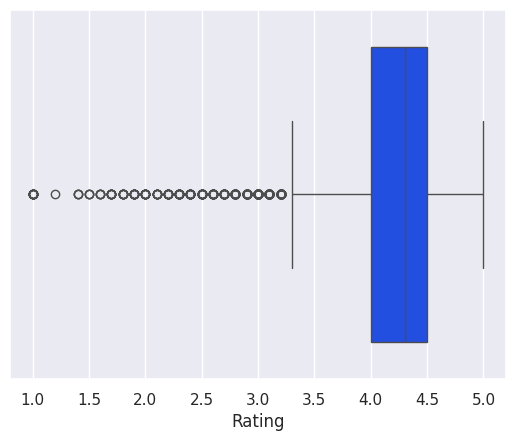

In [56]:
sns.boxplot(x = df['Rating'])

In [57]:
df['Installs'].skew()

np.float64(15.027397537641704)

In [58]:
df['log_installs'] = np.log1p(df['Installs'])
print(df['log_installs'].skew())

-0.2631571107607951


<Axes: xlabel='log_installs', ylabel='Count'>

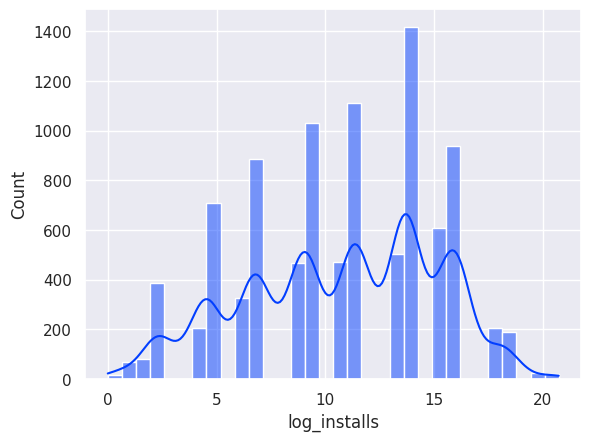

In [59]:
sns.histplot(df['log_installs'], kde=True)

<Axes: xlabel='log_installs'>

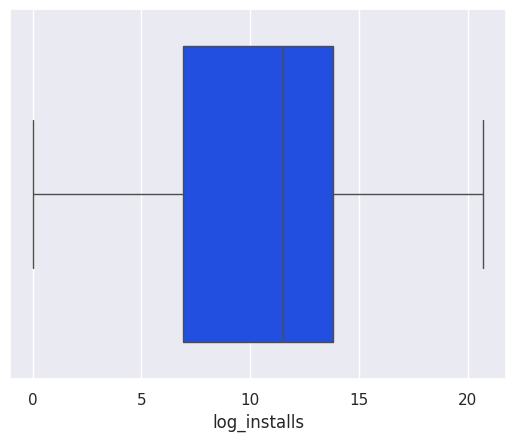

In [60]:
sns.boxplot(x = df['log_installs'])

<Axes: xlabel='Size', ylabel='Count'>

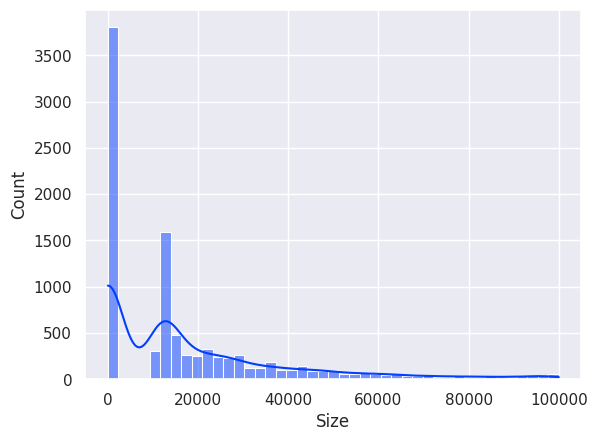

In [61]:
sns.histplot(df['Size'],kde = True)

In [62]:
df['log_size'] = np.log1p(df['Size'])
print(df['log_size'].skew())

-0.467114350028516


<Axes: xlabel='log_size', ylabel='Count'>

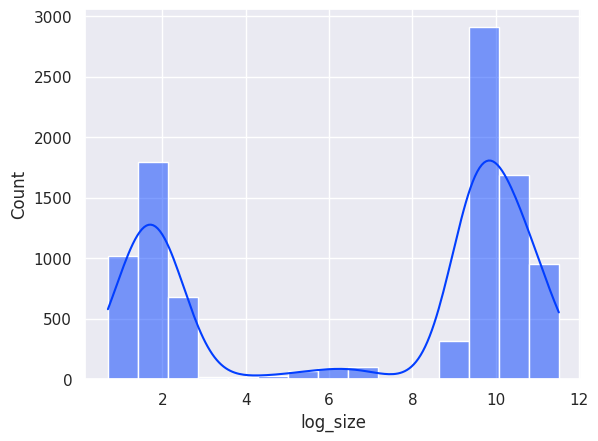

In [63]:
sns.histplot(df['log_size'],kde = True)

<Axes: xlabel='log_size'>

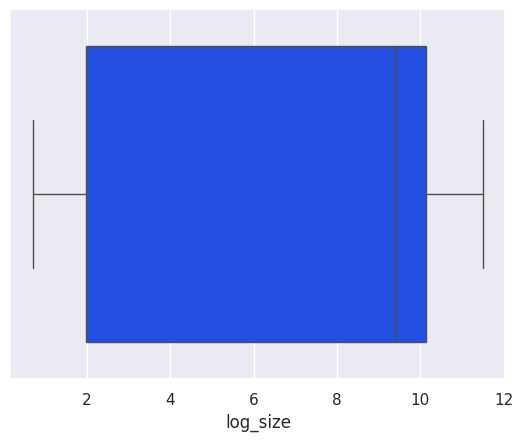

In [64]:
sns.boxplot(x = df['log_size'])

In [65]:
df['Price'].skew()

np.float64(22.532793401534324)

In [66]:
df['log_price'] = np.log1p(df['Price'])
df['log_price'].skew()

np.float64(5.859594386443212)

Text(0.5, 1.0, 'Free vs Paid apps')

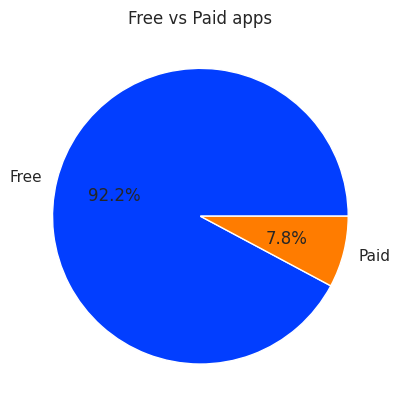

In [67]:
df['Type'].value_counts().plot.pie(autopct = '%1.1f%%')
plt.ylabel("")
plt.title("Free vs Paid apps")

## 💡 Conclusion
- Here first we have visualized the 'Reviews' column. What we observed was that the the data was highly skewed with skew value of 25.56. So we had to perform log normal distribution.
- After log normal distribution, the skew value for column 'Reviews' dropped to 0.04.
- Similarly for installs the skew value was 15.02 but after log transform, the value dropped to -0.26
- For price column, we can see that 92% of the apps are free to use which is a very huge number so even after performing the log transform, the skewed value was 5.85 so we cannot plot the values like that, what we can do is split the paid and free apps then try to plot the graph for paid apps
- For column 'Size', we had skew value of 1 still we performed log transform and the skew value dropped to -0.46
- For ratings there was no need of log transform but there are many outliers present so we need to clean them before model training.

## 🏷️ Categorical Feature

In [68]:
df['Category'].unique()

array(['SOCIAL', 'COMMUNICATION', 'GAME', 'TOOLS', 'VIDEO_PLAYERS',
       'NEWS_AND_MAGAZINES', 'PHOTOGRAPHY', 'FAMILY', 'TRAVEL_AND_LOCAL',
       'PERSONALIZATION', 'MAPS_AND_NAVIGATION', 'SHOPPING',
       'ENTERTAINMENT', 'PRODUCTIVITY', 'HEALTH_AND_FITNESS', 'SPORTS',
       'BOOKS_AND_REFERENCE', 'LIFESTYLE', 'WEATHER', 'FINANCE',
       'BUSINESS', 'EDUCATION', 'FOOD_AND_DRINK', 'COMICS', 'PARENTING',
       'DATING', 'HOUSE_AND_HOME', 'LIBRARIES_AND_DEMO', 'ART_AND_DESIGN',
       'AUTO_AND_VEHICLES', 'MEDICAL', 'BEAUTY', 'EVENTS'], dtype=object)

In [69]:
category_counts = df['Category'].value_counts()
top10 = category_counts.head(10)
others = category_counts.iloc[10:].sum()
top10['others'] = others

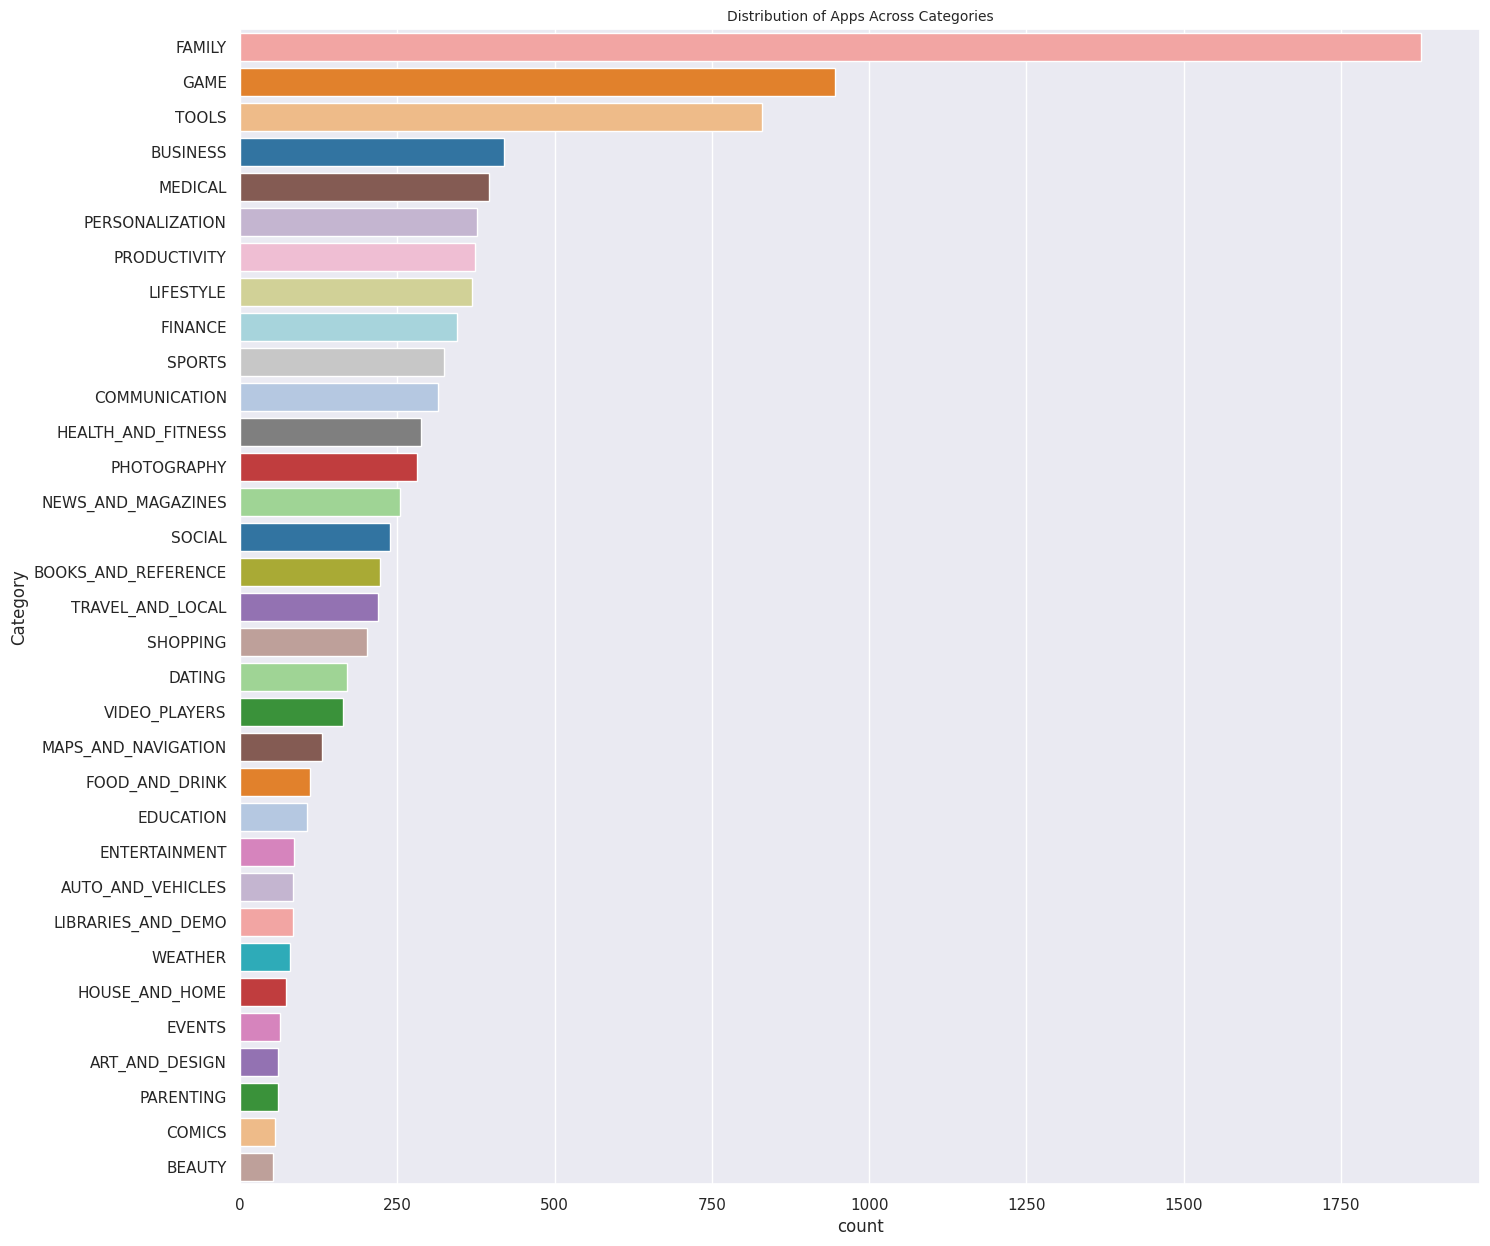

In [70]:
plt.figure(figsize = (16,15))


sns.countplot(
    y='Category',
    data=df,
    order=df['Category'].value_counts().index,
    hue='Category',
    palette='tab20',
    legend=False
)

plt.title("Distribution of Apps Across Categories", fontsize=10)
plt.show()

([<matplotlib.patches.Wedge at 0x7a91ca0561e0>,
 [Text(-0.6306002258569293, 0.9013009237481064, 'FAMILY'),
  Text(-1.0990092652576504, 0.04667584897824107, 'GAME'),
  Text(-0.9465484139009624, -0.5603981621504236, 'TOOLS'),
  Text(-0.6480678013716432, -0.8888240122911423, 'BUSINESS'),
  Text(-0.3925729302672942, -1.027563377325871, 'MEDICAL'),
  Text(-0.12530659617180345, -1.092839538521478, 'PERSONALIZATION'),
  Text(0.14235220630753628, -1.090750131496383, 'PRODUCTIVITY'),
  Text(0.3992494030813328, -1.0249877629216846, 'LIFESTYLE'),
  Text(0.6244297800274843, -0.9055867986089614, 'FINANCE'),
  Text(0.8054468538131467, -0.7491697842829111, 'SPORTS'),
  Text(0.9838715858437075, 0.49193160354808313, 'others')],
 [Text(-0.3439637595583251, 0.49161868568078526, '19.4%'),
  Text(-0.5994595992314457, 0.02545955398813149, '9.8%'),
  Text(-0.5162991348550704, -0.3056717248093219, '8.6%'),
  Text(-0.35349152802089623, -0.4848130976133503, '4.3%'),
  Text(-0.2141306892367059, -0.56048911490502

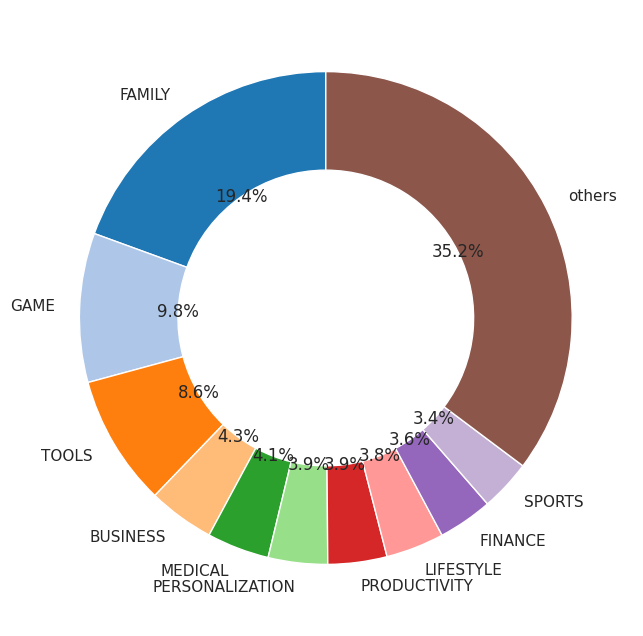

In [71]:
plt.figure(figsize = (8,8))
plt.pie(
    top10,
    labels = top10.index,
    autopct = '%1.1f%%',
    startangle = 90,
    colors = sns.color_palette('tab20'),
    wedgeprops = {'width':0.4}
)

In [72]:
df['Content Rating'].unique()

array(['Teen', 'Everyone', 'Everyone 10+', 'Mature 17+',
       'Adults only 18+', 'Unrated'], dtype=object)

In [73]:
df['Content Rating'].value_counts()

Content Rating
Everyone           7903
Teen               1036
Mature 17+          393
Everyone 10+        322
Adults only 18+       3
Unrated               2
Name: count, dtype: int64

In [74]:
filtered_df = df[~df['Content Rating'].isin(['Adults only 18+','Unrated'])]

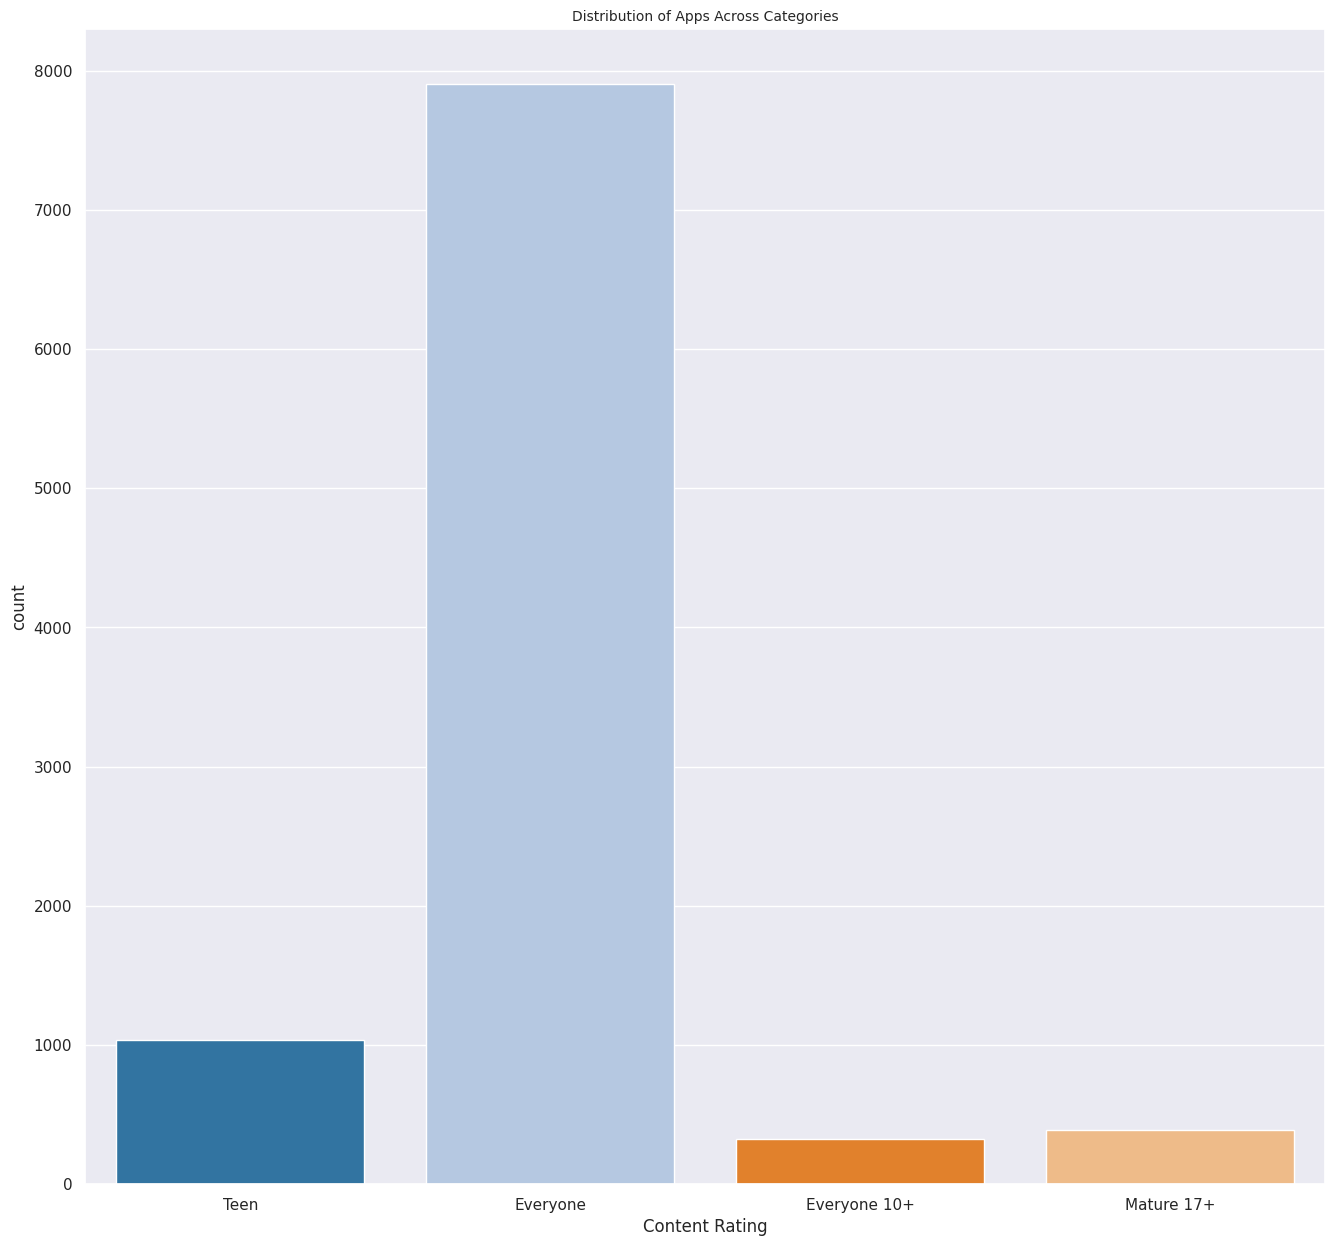

In [75]:
plt.figure(figsize = (16,15))


sns.countplot(
    x='Content Rating',
    data=filtered_df,
    hue='Content Rating',
    palette='tab20',
    legend=False
)

plt.title("Distribution of Apps Across Categories", fontsize=10)
plt.show()

In [76]:
content_counts = df['Content Rating'].value_counts()
total = content_counts.head(4)

In [77]:
total

Content Rating
Everyone        7903
Teen            1036
Mature 17+       393
Everyone 10+     322
Name: count, dtype: int64

([<matplotlib.patches.Wedge at 0x7a91c9e59a60>,
 [Text(-0.5934174279591725, -0.9262050292426188, 'Everyone'),
  Text(0.7909919849302744, 0.7644159075896214, 'Teen'),
  Text(0.3641997613929552, 1.0379588304944058, 'Mature 17+'),
  Text(0.1150522783276274, 1.0939666234632675, 'Everyone 10+')],
 [Text(-0.3236822334322759, -0.5052027432232465, '81.9%'),
  Text(0.4314501735983315, 0.41695413141252075, '10.7%'),
  Text(0.19865441530524824, 0.5661593620878577, '4.1%'),
  Text(0.06275578817870585, 0.5967090673436004, '3.3%')])

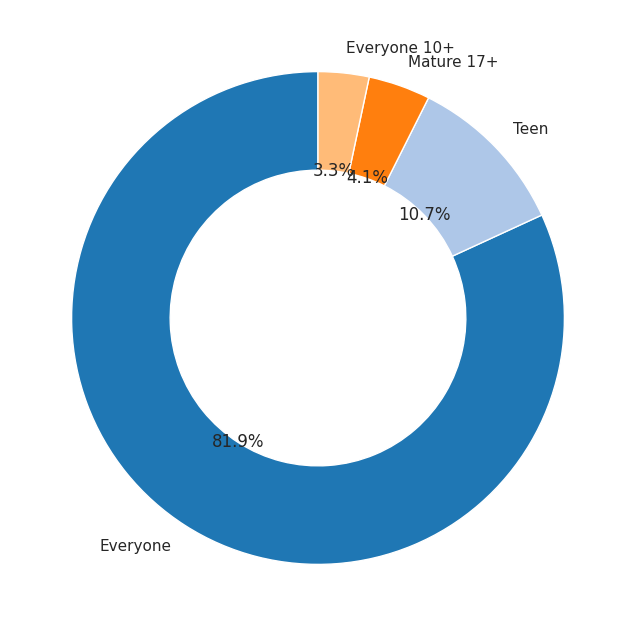

In [78]:
plt.figure(figsize = (8,8))
plt.pie(
    total,
    labels = total.index,
    autopct = '%1.1f%%',
    startangle = 90,
    colors = sns.color_palette('tab20'),
    wedgeprops = {'width':0.4}
)

In [79]:
df['Genres'].unique()

array(['Social', 'Communication', 'Strategy', 'Tools', 'Arcade',
       'Video Players & Editors', 'Casual', 'Sports', 'News & Magazines',
       'Action', 'Photography', 'Adventure', 'Casual;Action & Adventure',
       'Travel & Local', 'Racing', 'Personalization', 'Maps & Navigation',
       'Entertainment', 'Trivia', 'Education;Education', 'Shopping',
       'Productivity', 'Health & Fitness', 'Adventure;Action & Adventure',
       'Simulation', 'Books & Reference', 'Lifestyle', 'Role Playing',
       'Arcade;Action & Adventure', 'Weather', 'Puzzle', 'Casino', 'Card',
       'Word', 'Puzzle;Action & Adventure', 'Sports;Action & Adventure',
       'Board', 'Finance', 'Puzzle;Brain Games',
       'Racing;Action & Adventure', 'Business', 'Education',
       'Food & Drink', 'Educational;Pretend Play', 'Comics',
       'Card;Action & Adventure', 'Music',
       'Educational;Action & Adventure', 'Parenting',
       'Simulation;Action & Adventure', 'Role Playing;Action & Adventure',
      

In [80]:
df['Genres'].value_counts().head(28)

Genres
Tools                      828
Entertainment              561
Education                  510
Business                   420
Medical                    395
Personalization            376
Productivity               374
Lifestyle                  368
Finance                    345
Sports                     331
Communication              315
Action                     299
Health & Fitness           288
Photography                281
News & Magazines           254
Social                     239
Books & Reference          222
Travel & Local             218
Shopping                   202
Simulation                 193
Arcade                     184
Dating                     170
Casual                     165
Video Players & Editors    162
Maps & Navigation          131
Puzzle                     119
Food & Drink               112
Role Playing               105
Name: count, dtype: int64

In [81]:
genre_counts = df['Genres'].value_counts()

top28 = genre_counts.head(28)
others = genre_counts.iloc[28:].sum()
top28['others'] = others

Text(0, 0.5, 'Genres')

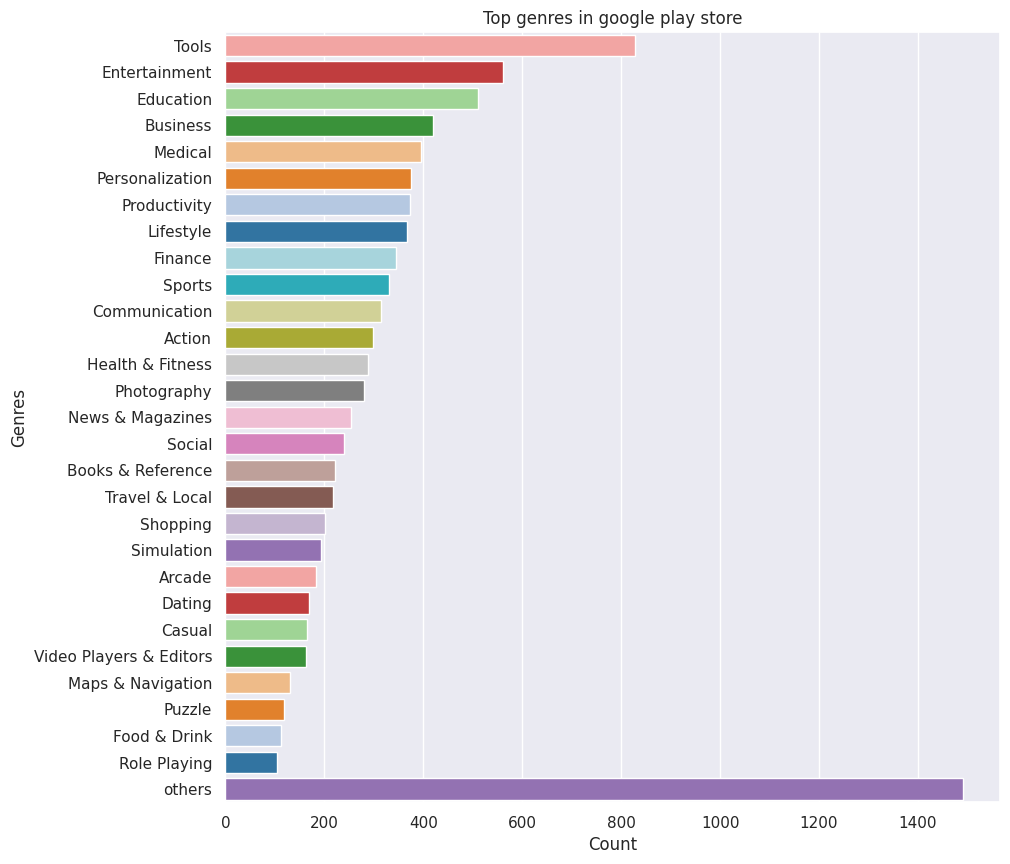

In [82]:
plt.figure(figsize = (10,10))
sns.barplot(
    x = top28.values,
    hue = top28.values,
    y = top28.index,
    palette = 'tab20',
    legend = False
)
plt.title("Top genres in google play store")
plt.xlabel("Count")
plt.ylabel("Genres")

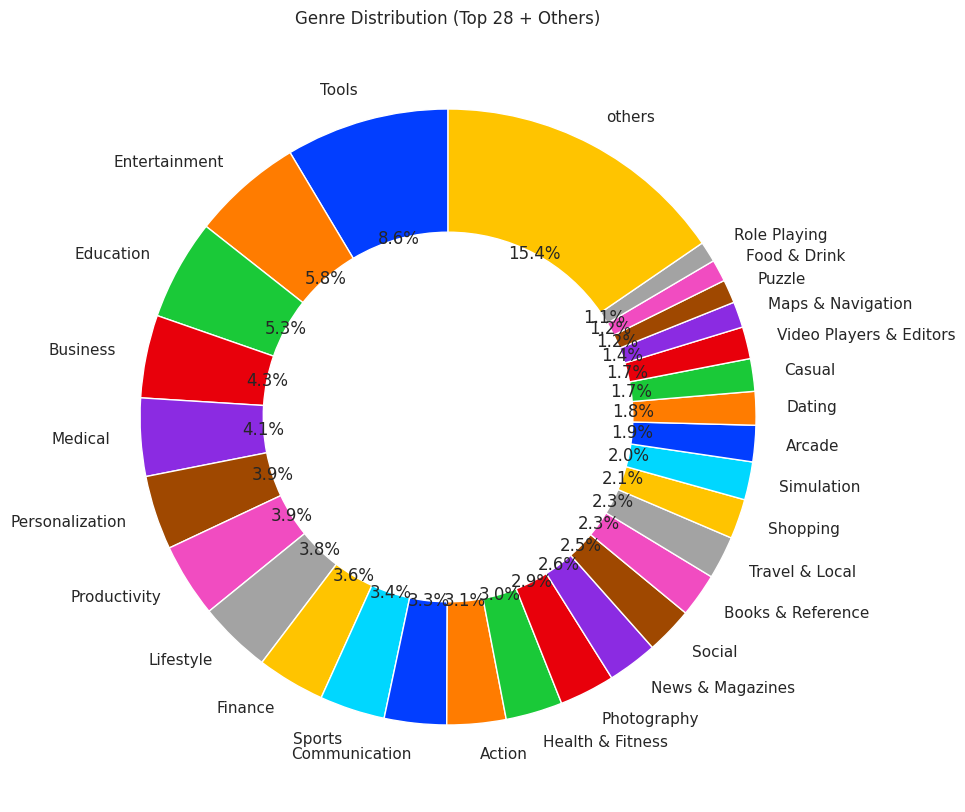

In [83]:
plt.figure(figsize=(10,10))

plt.pie(
    top28,
    labels=top28.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width':0.4}
)

plt.title("Genre Distribution (Top 28 + Others)")

plt.show()

## 💡 Conclusion
- Here when we talk about the category, we can see that the maximum apps has the category as family in the data set followed by the games category and then the tools category. When we compare it with other category, other category only forms 35.2% of the dataset rest all the dataset is consumed by top 10 categories.
- Now when we see the content rating column, maximum dataset has content rating as 'everyone' which is 81.9% of the data set. there are 2 values 'Adults only 18+' which as count of 3 and 'Unrated' which has a count of 2 so both as a very low significance in the data set hence we encluded then while plotting the graph.
- Now the last categorical feature that i analyized is genre here tools genre holds 8.6% of the dataset followed by entertainment: 5.8% and education 5.3%.

# 📊 Visualization: Bivariate Analysis

## Top 10 category based on installs

In [84]:
top_cat = df.groupby('Category')['Installs'].mean().sort_values(ascending = False).head(10)

In [85]:
top_cat

Category
COMMUNICATION         3.504215e+07
VIDEO_PLAYERS         2.397502e+07
SOCIAL                2.296179e+07
PHOTOGRAPHY           1.657704e+07
PRODUCTIVITY          1.548955e+07
GAME                  1.423061e+07
TRAVEL_AND_LOCAL      1.321866e+07
ENTERTAINMENT         1.144953e+07
TOOLS                 9.774152e+06
NEWS_AND_MAGAZINES    9.327629e+06
Name: Installs, dtype: float64

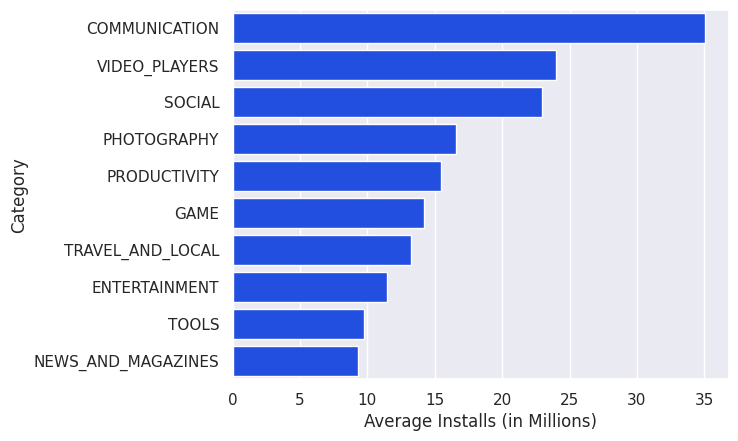

In [86]:
total_cat_million = top_cat / 1000000
ax = sns.barplot(x = total_cat_million.values, y = total_cat_million.index)
ax.set_xlabel("Average Installs (in Millions)")
plt.show()

### 💡 Conclusion
- Communication app have the highest average installs (~35M), followed by video players and social categories.
- This indicates that apps focused on connectivity, content consumption and social interaction dominate user engagement in the play store.
- Categories like Photography and productivity also show strong performance, suggesting consistent demand for utility based applications.

## Type(free/paid) vs installs

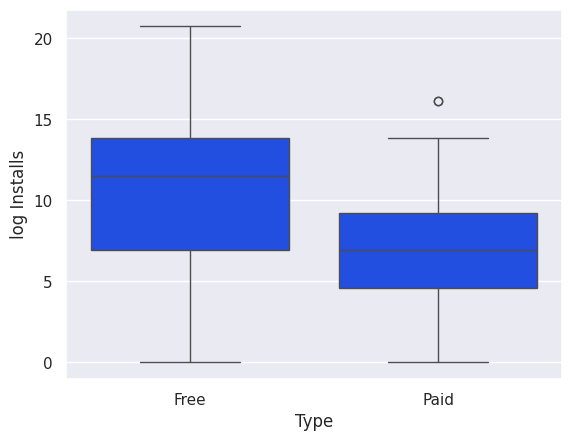

In [87]:
sns.boxplot(x = 'Type',y = 'log_installs',data = df)
plt.ylabel('log Installs')
plt.show()

## 💡 Conclusion
- Here we can see that free apps have higher median than the paid once which means that free apps are more popular.
- Free apps have wider spread than the paid apps which means that free have more high volume hits then the paid apps.
- paid apps have very few high end outlier which shows that there are very few high installs paid apps

## relation between rating and review

<Axes: xlabel='Reviews_log', ylabel='Rating'>

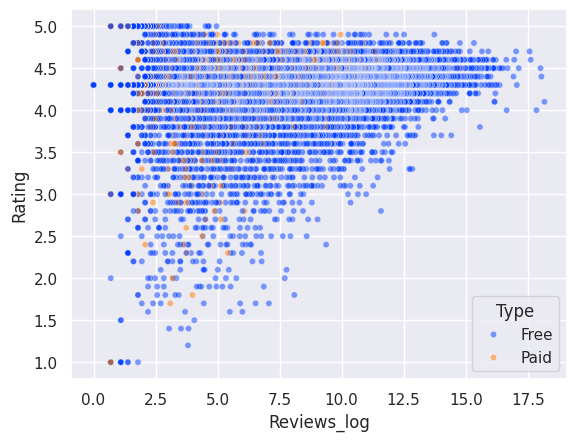

In [88]:
sns.scatterplot(x = 'Reviews_log',y = 'Rating',data = df,hue = 'Type',s = 20,alpha = 0.5)

### 💡 Conclusion
- There is a slight positive relationship between the number of reviews and app ratings, indicating that more popular apps tend to have better ratings.
- However, the correlation is weak. Apps with fewer reviews show high variability in ratings, while highly reviewed apps have more stable ratings concentrated around 4.0–4.5.
- Additionally, free apps dominate the dataset, and no significant difference is observed in rating patterns between free and paid apps.

<Axes: xlabel='log_price', ylabel='log_installs'>

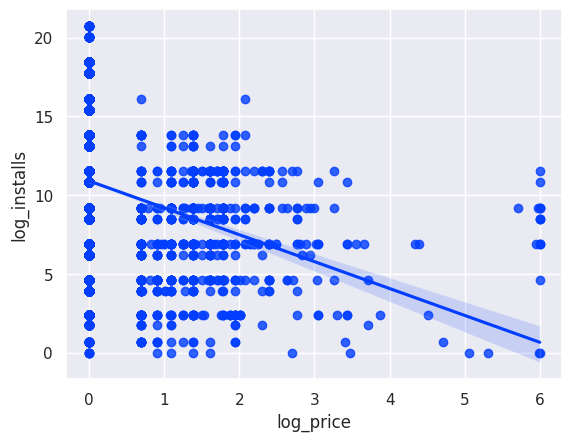

In [89]:
df['log_price'] = np.log1p(df['Price'])

sns.regplot(
    x='log_price',
    y='log_installs',
    data=df,
)

### 💡 Conclusion
- After applying log transformation to both price and installs, a clearer inverse relationship is observed.
- As the price of an app increases, the number of installs generally decreases, indicating a negative correlation.
- Free apps dominate in terms of downloads, achieving significantly higher install counts compared to paid apps.
- However, the wide spread of points suggests that price alone does not determine installs, and other factors such as app quality, category, and user engagement also play an important role.

## Top 10 category based on rating

(array([0., 1., 2., 3., 4., 5., 6.]),
 [Text(0.0, 0, '0'),
  Text(1.0, 0, '1'),
  Text(2.0, 0, '2'),
  Text(3.0, 0, '3'),
  Text(4.0, 0, '4'),
  Text(5.0, 0, '5'),
  Text(6.0, 0, '6')])

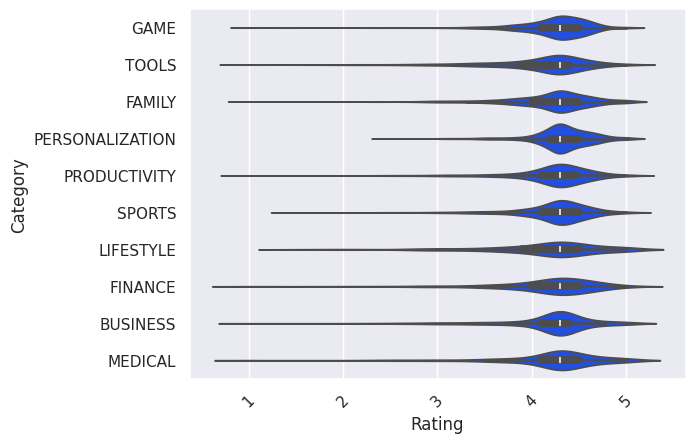

In [90]:
top_cat = df['Category'].value_counts().head(10).index
df_top = df[df['Category'].isin(top_cat)]

sns.violinplot(y='Category', x='Rating', data=df_top)
plt.xticks(rotation=45)

### 💡 Conclusion
- The violin plot shows that app ratings are consistently high across all major categories, with most values concentrated between 4.0 and 4.5.
- There is minimal variation in median ratings across categories, indicating that category does not significantly influence app ratings.
- However, some categories exhibit slightly higher variability, and all categories contain a small number of low-rated apps.

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Teen'),
  Text(1, 0, 'Everyone'),
  Text(2, 0, 'Everyone 10+'),
  Text(3, 0, 'Mature 17+'),
  Text(4, 0, 'Adults only 18+'),
  Text(5, 0, 'Unrated')])

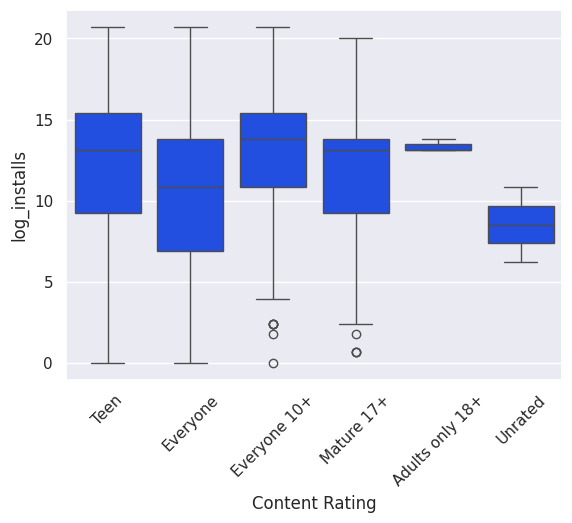

In [91]:
sns.boxplot(x = 'Content Rating', y = 'log_installs',data = df)
plt.xticks(rotation = 45)

### 💡 Conclusion
- The categories "Everyone 10+", "Teen", and "Mature 17+" show the highest median install values. They also have very similar upper ranges, suggesting that apps in these categories have the highest potential for reaching massive scales.
- The "Unrated" category has a significantly lower median and overall range compared to all other categories, indicating these apps generally struggle to gain traction.
- The "Adults only 18+" category has a very small "box" and short whiskers. This indicates that while there may be fewer apps in this category, their install numbers are much more consistent (clustered around a specific log value) than other categories.
- The "Everyone" and "Teen" categories have the longest whiskers extending toward zero. This means these categories contain everything from total failures (0 installs) to massive hits, making them the most unpredictable ratings.
- "Everyone 10+" and "Mature 17+" both show several low-end outliers (the small circles near the bottom). This suggests a few specific apps in these groups performed significantly worse than the general trend for their rating.

# 📊 Correlation Analysis

In [92]:
num_df = df[['Rating','Reviews_log','log_installs','log_price']]

In [93]:
corr = num_df.corr()
corr

,Rating,Reviews_log,log_installs,log_price
Rating,1.000000,0.093989,0.011245,0.023063
Reviews_log,0.093989,1.000000,0.958784,-0.124034
log_installs,0.011245,0.958784,1.000000,-0.194582
log_price,0.023063,-0.124034,-0.194582,1.000000


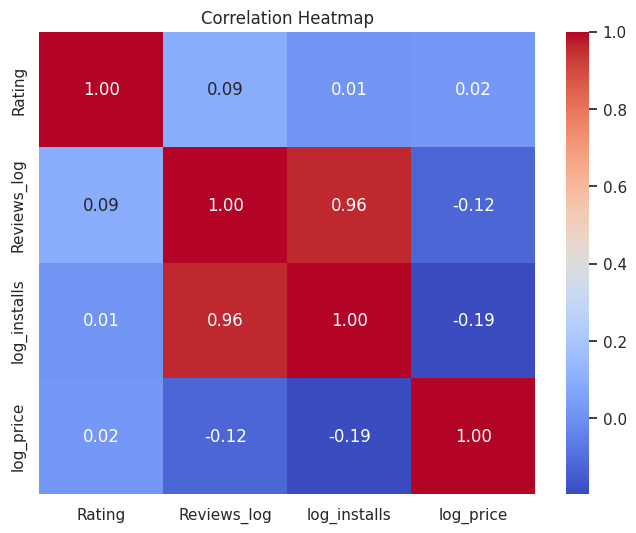

In [94]:
plt.figure(figsize = (8,6))
sns.heatmap(
    corr,
    annot = True,
    cmap = 'coolwarm',
    fmt = '.2f'
)

plt.title("Correlation Heatmap")
plt.show()

## 💡 Conclusion

- A very strong positive correlation (0.96) exists between reviews and installs, indicating that more popular apps tend to receive significantly higher user engagement.
- Price shows a weak negative correlation with installs (-0.19), suggesting that higher-priced apps generally have fewer downloads, although the impact is limited.
- Similarly, price has a weak negative relationship with reviews (-0.12), implying that paid apps tend to receive fewer user interactions.
- Ratings exhibit negligible correlation with installs and reviews, indicating that app popularity does not necessarily reflect user satisfaction.
- Overall, engagement-related metrics (installs and reviews) are strongly interconnected, while price and rating have minimal influence.

# 📌 Final Conclusion:

- This exploratory data analysis of the Google Play Store dataset provides key insights into app performance, user engagement, and feature relationships.

- From a data preprocessing perspective, duplicate entries were removed based on the *App* feature to ensure entity-level uniqueness, while missing values were handled using appropriate statistical imputations (median for skewed numerical features and mode for categorical variables). Additionally, log transformations were applied to highly skewed features such as *Installs* and *Reviews*, significantly improving distribution symmetry and enabling more meaningful statistical analysis.

- Univariate analysis revealed that most apps are concentrated in a few dominant categories, with a heavy imbalance toward free applications. Numerical features such as installs and reviews exhibited strong right-skewness, indicating the presence of a small number of highly popular apps driving the majority of engagement.

- Bivariate analysis highlighted several important patterns. Free apps consistently demonstrated higher install counts compared to paid apps, suggesting that pricing plays a critical role in user acquisition. Category-wise comparisons showed that certain categories dominate in terms of installs and user engagement, reflecting user preference trends within the platform. However, rating distributions remained relatively stable across different segments, indicating limited variation in perceived app quality.

- Correlation analysis further quantified these relationships. A very strong positive correlation was observed between installs and reviews, confirming that user engagement scales proportionally with app popularity. In contrast, price exhibited a weak negative correlation with installs and reviews, suggesting that while higher-priced apps may deter some users, pricing alone is not a dominant factor. Notably, ratings showed negligible correlation with both installs and reviews, implying that app success is more closely tied to visibility and reach rather than user satisfaction metrics.

- Overall, the analysis suggests that app success in the Google Play Store ecosystem is primarily driven by accessibility (free vs paid), visibility, and network effects reflected through installs and reviews, rather than intrinsic quality indicators such as ratings. This highlights the importance of distribution strategies and user acquisition mechanisms over purely product-centric factors.

- These insights can be further extended through predictive modeling or segmentation analysis to better understand drivers of app growth and user engagement.


# 🚀 Future Scope

While this exploratory data analysis provides meaningful insights into app performance and user engagement, several advanced extensions can be implemented to further enhance the analysis:

**1. Predictive Modeling**

* Build regression models to predict app installs based on features such as reviews, price, category, and rating.
* Algorithms such as Linear Regression, Random Forest, and Gradient Boosting can be applied.
* This can help identify key drivers influencing app popularity.

**2. Classification Tasks**

* Convert installs into categories (e.g., Low, Medium, High) and build classification models.
* This can help predict whether a newly launched app is likely to succeed.

**3. Feature Engineering**

* Extract additional features such as:

  * App age (from last updated)
  * Price buckets (Free, Low, Premium)
  * Category-level aggregates
* These engineered features can improve model performance.

**4. Clustering & Segmentation**

* Apply clustering algorithms (e.g., K-Means) to group apps based on installs, reviews, and ratings.
* This can reveal hidden patterns such as high-performing vs low-performing app segments.

**5. Time-Based Analysis**

* Analyze trends based on the “Last Updated” feature to understand how app updates impact installs and ratings over time.

**6. Recommendation System**

* Build a simple recommendation system to suggest apps based on user preferences, category, and ratings.

**7. Advanced Visualization Dashboard**

* Create an interactive dashboard using tools like Plotly or Power BI for real-time exploration of app metrics.

Overall, these extensions can transform the current analysis into a complete data science project involving prediction, segmentation, and decision-making systems.
